In [1]:
!pip install -U scikit-learn imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 51.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv
/kaggle/input/attrition-in-an-organization-why-workers-quit/Rplot001.png
/kaggle/input/attrition-in-an-organization-why-workers-quit/__results__.html
/kaggle/input/attrition-in-an-organization-why-workers-quit/__notebook__.ipynb
/kaggle/input/attrition-in-an-organization-why-workers-quit/__output__.json
/kaggle/input/attrition-in-an-organization-why-workers-quit/custom.css
/kaggle/input/attrition-in-an-organization-why-workers-quit/__results___files/__results___47_0.png
/kaggle/input/attrition-in-an-organization-why-workers-quit/__results___files/__results___67_0.png
/kaggle/input/attrition-in-an-organization-why-workers-quit/__results___files/__results___39_0.png
/kaggle/input/attrition-in-an-organization-why-workers-quit/__results___files/__results___20_0.png
/kaggle/input/attrition-in-an-organization-why-workers-quit/__results___files/__results___14_0.png
/kaggle/input/attrition-in-an-organization

In [3]:

att_df = pd.read_csv("/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv",header = 0)
att_df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
att_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
att_df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
att_df['Attrition'] = le.fit_transform(att_df['Attrition'])
att_df['OverTime']=le.fit_transform(att_df['OverTime'])
att_df['Gender']=le.fit_transform(att_df['Gender'])

In [7]:
att_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   int64 
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
att_df['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

# **Exploratory Data Analysis**

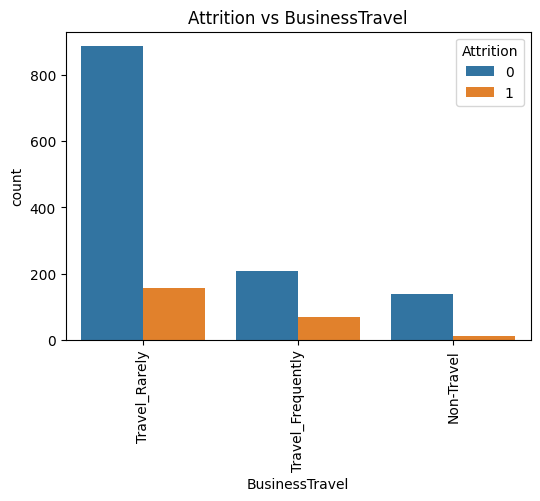

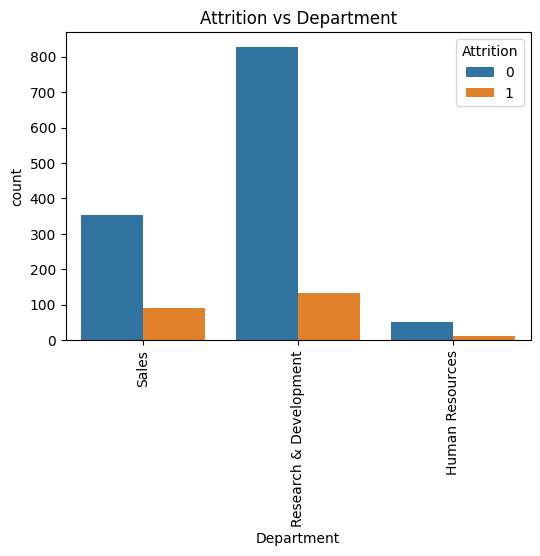

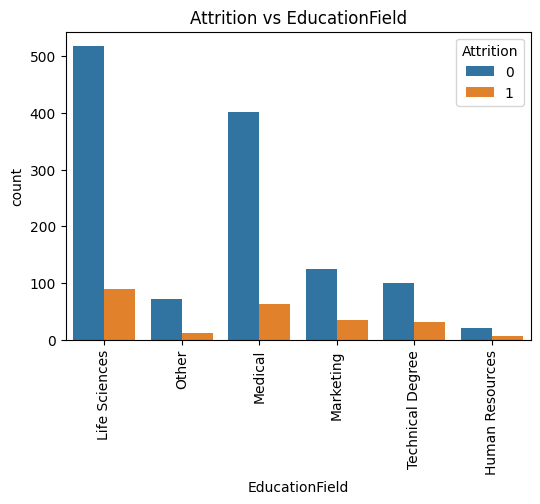

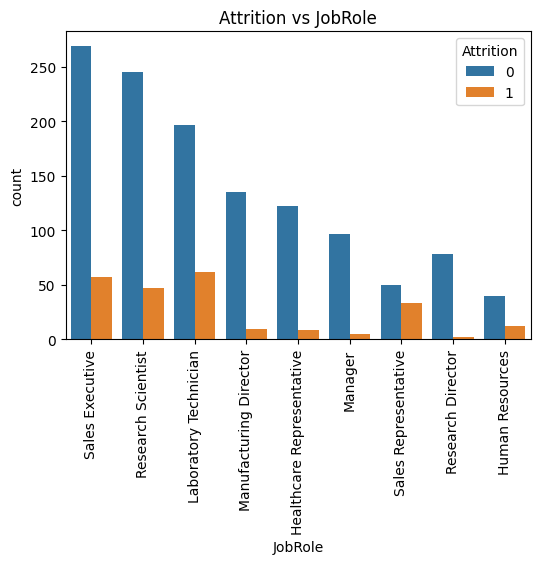

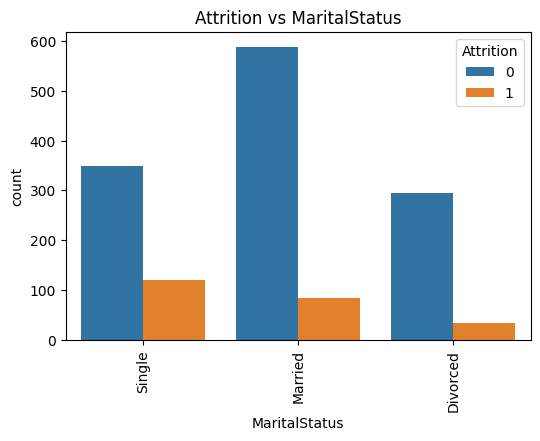

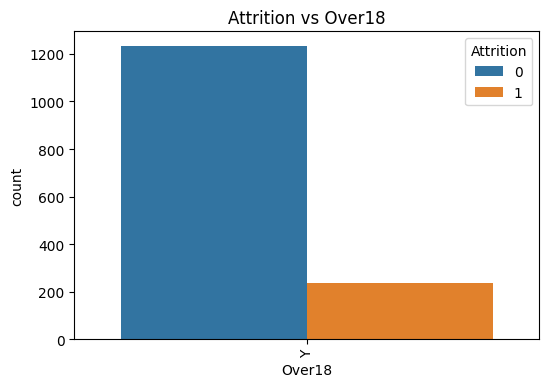

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_df = att_df.select_dtypes(include='object')
# Example: plot boxplots for each categorical column vs Attrition
for col in cat_df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue ='Attrition', data=att_df)
    plt.xticks(rotation=90)
    plt.title(f'Attrition vs {col}')
    plt.show()

<Figure size 500x1000 with 0 Axes>

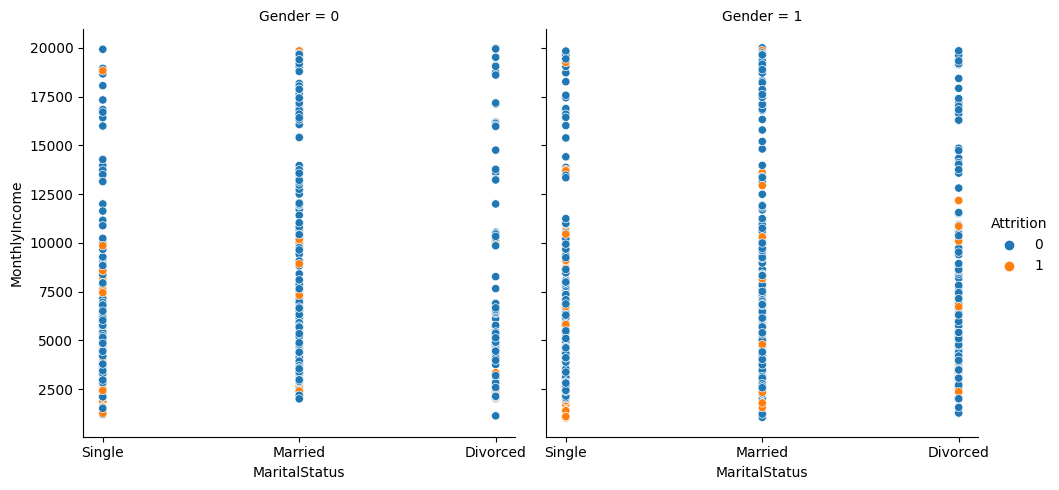

In [22]:
plt.figure(figsize=(5,10))
sns.relplot(data=att_df, y="MonthlyIncome", x="MaritalStatus", hue="Attrition",col='Gender')
plt.show()

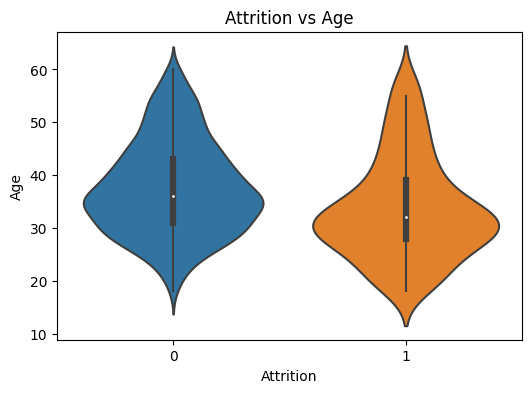

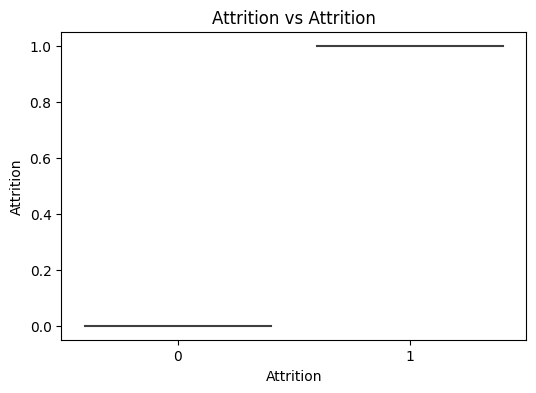

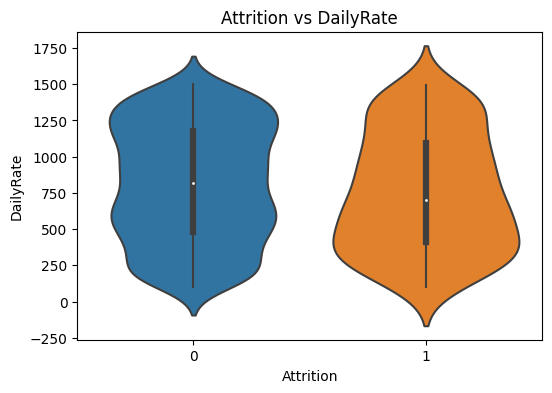

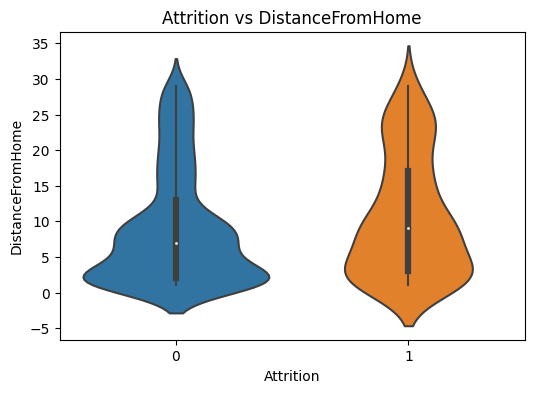

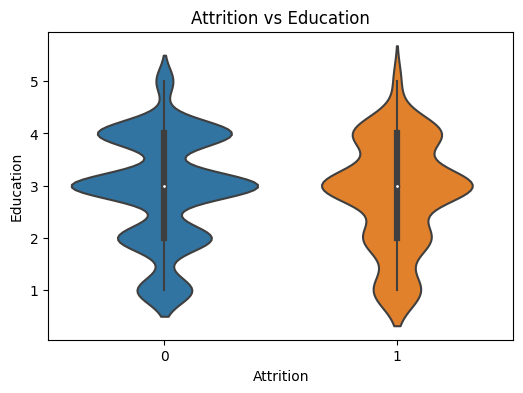

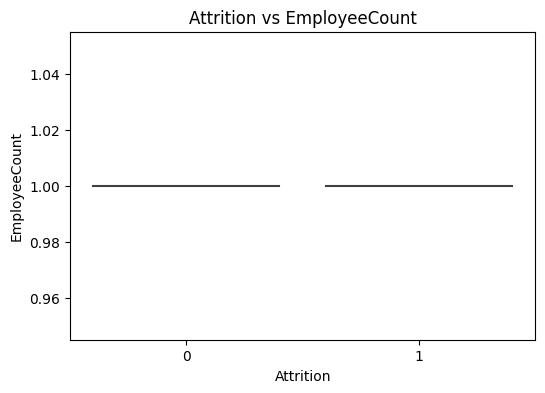

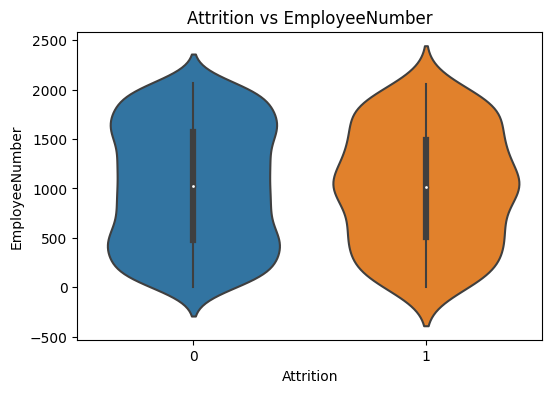

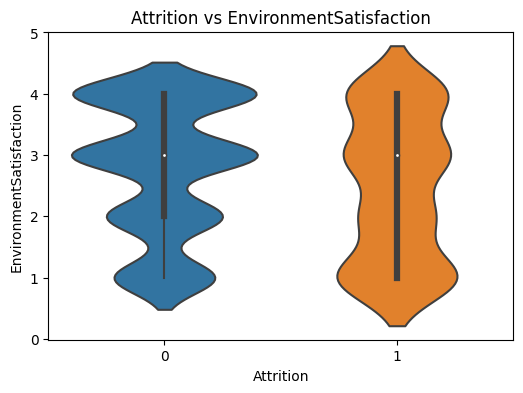

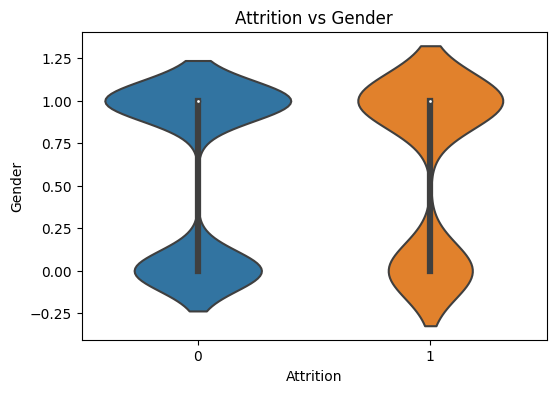

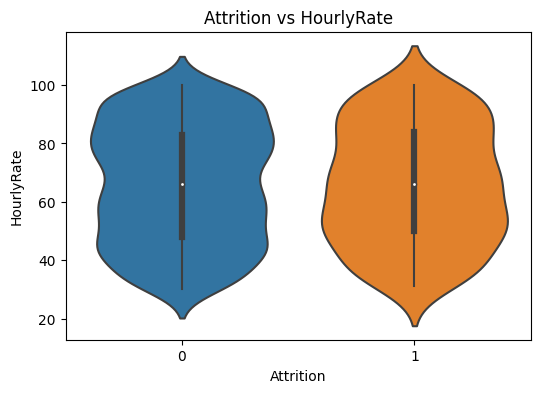

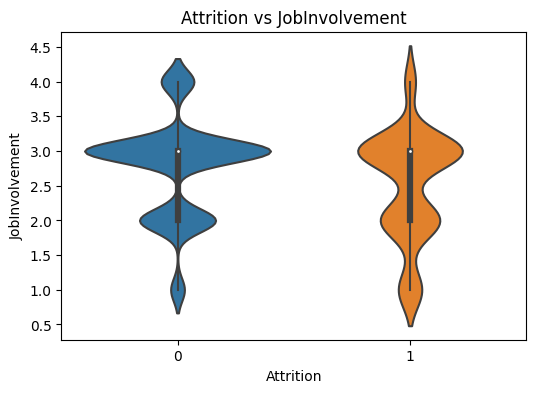

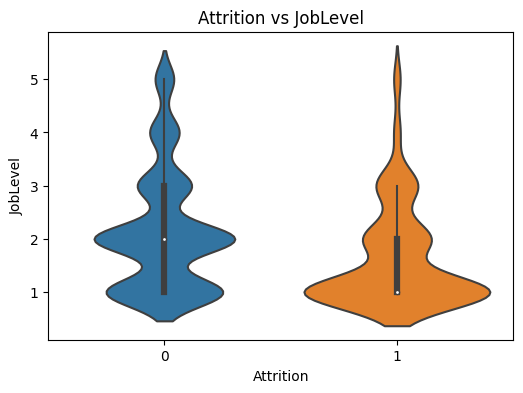

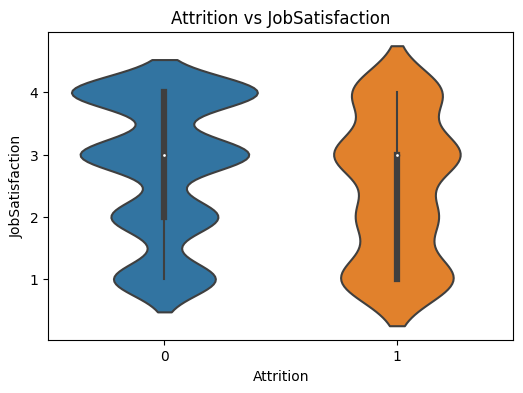

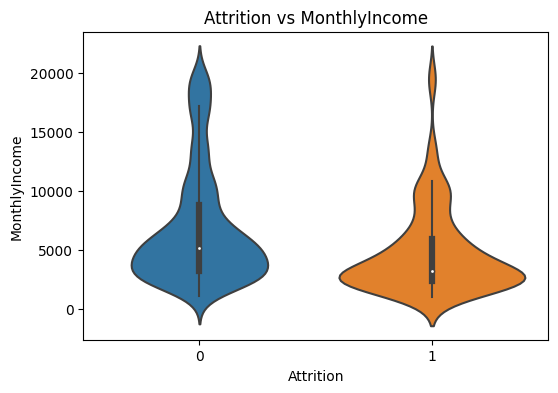

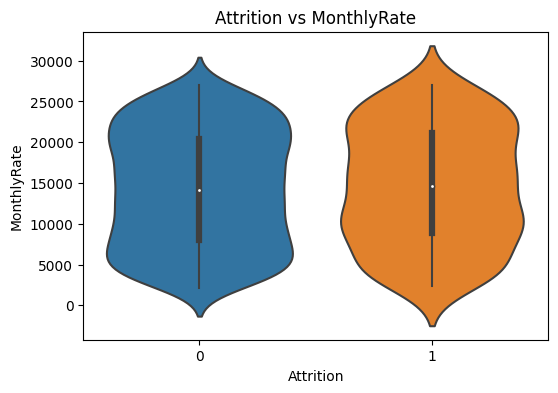

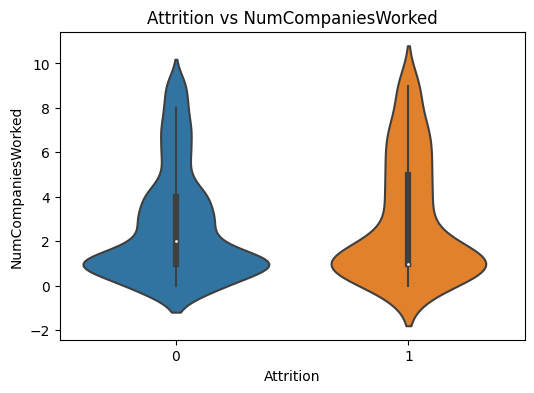

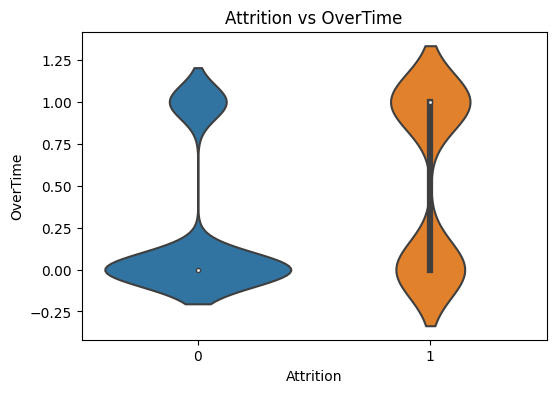

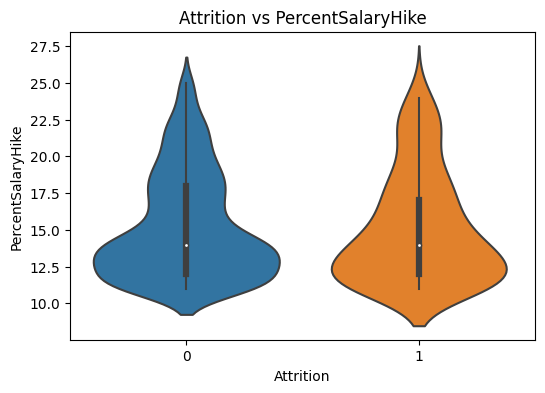

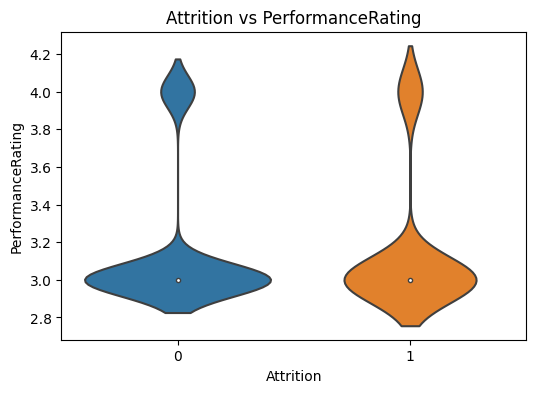

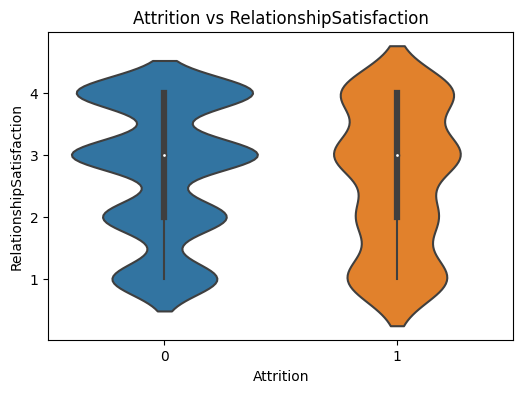

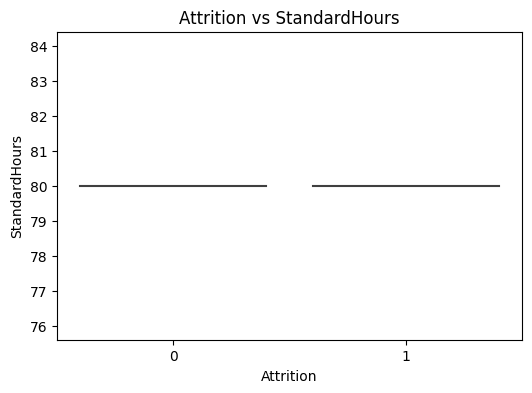

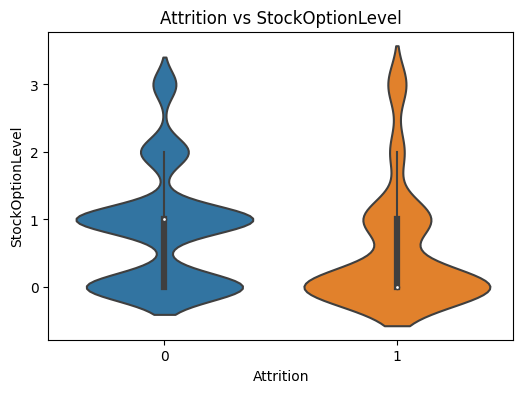

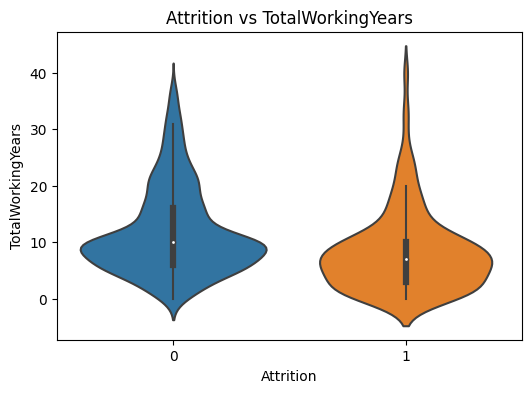

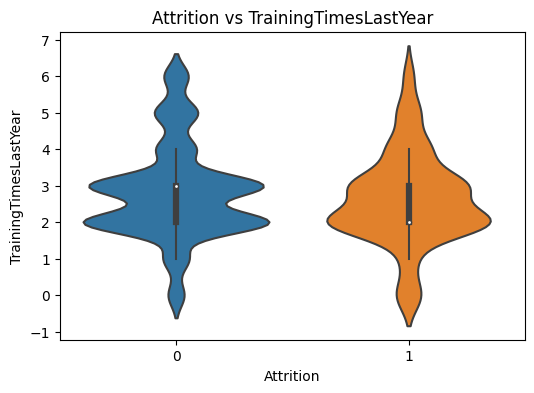

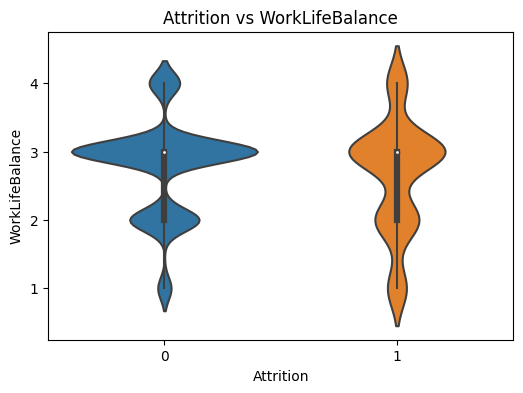

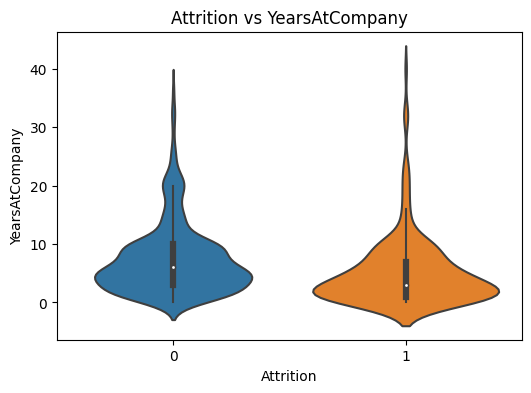

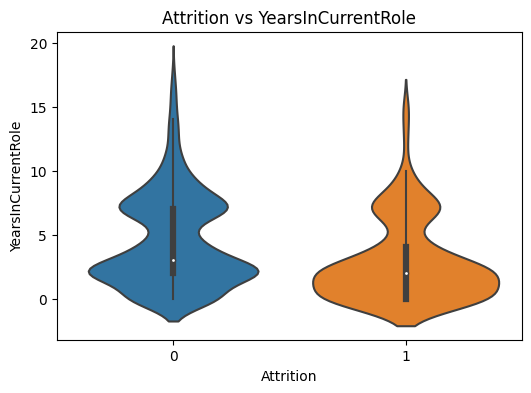

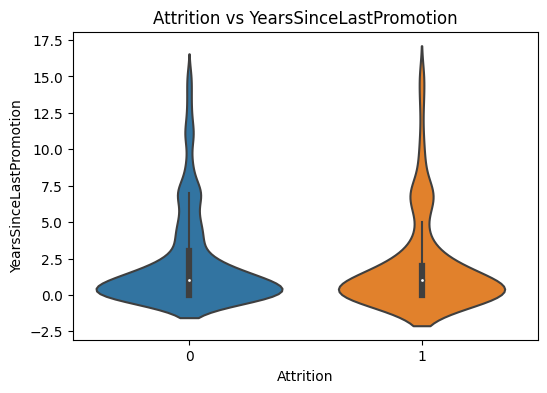

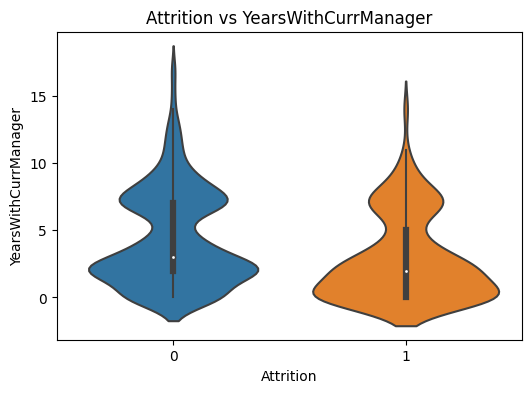

In [10]:
num_df = att_df.select_dtypes(exclude='object')

# Example: plot regplots for each numerical column vs Attrition
for col in num_df.columns:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x='Attrition', y=col, data=att_df)
    #plt.xticks(rotation=90) 
    #plt.ylabel('Attrition')
    plt.title(f'Attrition vs {col}')
    plt.show()

# Summary

The employee attrition analysis reveals key behavioral and organizational patterns influencing turnover. Factors such as compensation, job level, commute distance, and managerial relationships play a critical role in employee retention. The findings highlight that **competitive pay, career advancement, consistent leadership, and professional development opportunities can significantly reduce attrition rates and improve workforce stability.**

# Key Insights From Employee attrition analysis:

**Age and Attrition:**
Attrition rates decline notably after the age of 35, indicating that older employees tend to stay longer with the company.

**Distance from Home:**
Employees who live more than 12 km away from the workplace show higher attrition, suggesting that long commutes may contribute to employee turnover.

**Job Level:**
Attrition is highest among employees at Job Level 1, but it decreases sharply after Job Level 3, indicating that higher-level positions experience better retention.

**Monthly Income:**
Employees earning below 5,000 per month exhibit significantly higher attrition, while attrition drops substantially for those earning above $10,000.

**Overtime Impact:**
Employees required to work overtime have a much higher likelihood of leaving compared to those who maintain regular working hours.

**Salary Hike Percentage:**
A salary increase of 18% or more is associated with a noticeable reduction in attrition, highlighting the importance of competitive compensation.

**Stock Option Level:**
Attrition rates are significantly lower for employees with stock option levels 3 and 4, suggesting that long-term financial incentives improve retention.

**Years of Experience:**
Attrition drops sharply for employees with over 10 years at the company or more than 20 years in the industry, indicating higher loyalty among experienced workers.

**Training Opportunities:**
Employees who attended 3 to 4 training sessions in the last year showed reduced attrition, suggesting that learning and development opportunities encourage retention.

**Relationship with Manager:**
Employees who have worked with their current manager for over 5 years show a lower attrition rate, emphasizing the importance of stable and supportive management relationships.

**Marital Status:**
Divorced female employees show very little to no attrition, suggesting that marital status — particularly among divorced women — may be associated with higher job stability or commitment levels.

**Job Role:**
Employees working as Sales Executives, Research Scientists, Laboratory Technicians, and Sales Representatives exhibit a higher attrition rate compared to other job roles, indicating that these positions may have greater work pressure, job mobility, or lower satisfaction levels.

**Education Field:**
Employees from Life Sciences and Medical education fields show a comparatively higher attrition rate, suggesting that professionals in these domains may experience greater career opportunities elsewhere or higher job-related stress, leading to increased turnover.

**Business Travel and Department:**
Employees who never engage in business travel exhibit very low to almost zero attrition rates. Similarly, those working in the Human Resources department show minimal turnover, indicating higher job stability in these groups.

In [11]:
num_df.corr()['Attrition']

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Age                        -0.159205
Attrition                   1.000000
DailyRate                  -0.056652
DistanceFromHome            0.077924
Education                  -0.031373
EmployeeCount                    NaN
EmployeeNumber             -0.010577
EnvironmentSatisfaction    -0.103369
Gender                      0.029453
HourlyRate                 -0.006846
JobInvolvement             -0.130016
JobLevel                   -0.169105
JobSatisfaction            -0.103481
MonthlyIncome              -0.159840
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
OverTime                    0.246118
PercentSalaryHike          -0.013478
PerformanceRating           0.002889
RelationshipSatisfaction   -0.045872
StandardHours                    NaN
StockOptionLevel           -0.137145
TotalWorkingYears          -0.171063
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
YearsAtCompany             -0.134392
YearsInCurrentRole         -0.160545
Y

In [12]:
from sklearn.preprocessing import OneHotEncoder

# Separate categorical and numerical columns
cat_df = att_df.select_dtypes(include='object')
cat_df.drop('Over18',axis=1,inplace =True)
num_df = att_df.select_dtypes(exclude='object')

num_df.drop(columns = ['YearsSinceLastPromotion', 'WorkLifeBalance', 'RelationshipSatisfaction', 'StandardHours', 'PercentSalaryHike', 'PerformanceRating', 'NumCompaniesWorked', 'MonthlyRate', 'HourlyRate', 'EmployeeNumber', 'EmployeeCount', 'Education', 'DailyRate'],axis = 1, inplace = True)

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' avoids dummy trap (optional)

# Fit and transform categorical data
cat_encoded = encoder.fit_transform(cat_df)

# Convert encoded array to DataFrame
cat_encoded_df = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(cat_df.columns))

# Combine numeric and encoded categorical data
encoded_df = pd.concat([num_df.reset_index(drop=True), cat_encoded_df.reset_index(drop=True)], axis=1)

# Final encoded DataFrame
encoded_df.head()


,Age,Attrition,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,2,0,3,2,4,5993,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,49,0,8,3,1,2,2,2,5130,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,2,4,1,2,1,3,2090,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,33,0,3,4,0,3,1,3,2909,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,27,0,2,1,1,3,1,2,3468,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
#encoded_df.drop(columns = ['YearsSinceLastPromotion', 'WorkLifeBalance', 'TrainingTimesLastYear', 'RelationshipSatisfaction', 'StandardHours', 'PercentSalaryHike', 'PerformanceRating', 'NumCompaniesWorked', 'MonthlyRate', 'HourlyRate', 'EmployeeNumber', 'EmployeeCount', 'Education', 'DailyRate','Over18'],axis = 1, inplace = True)

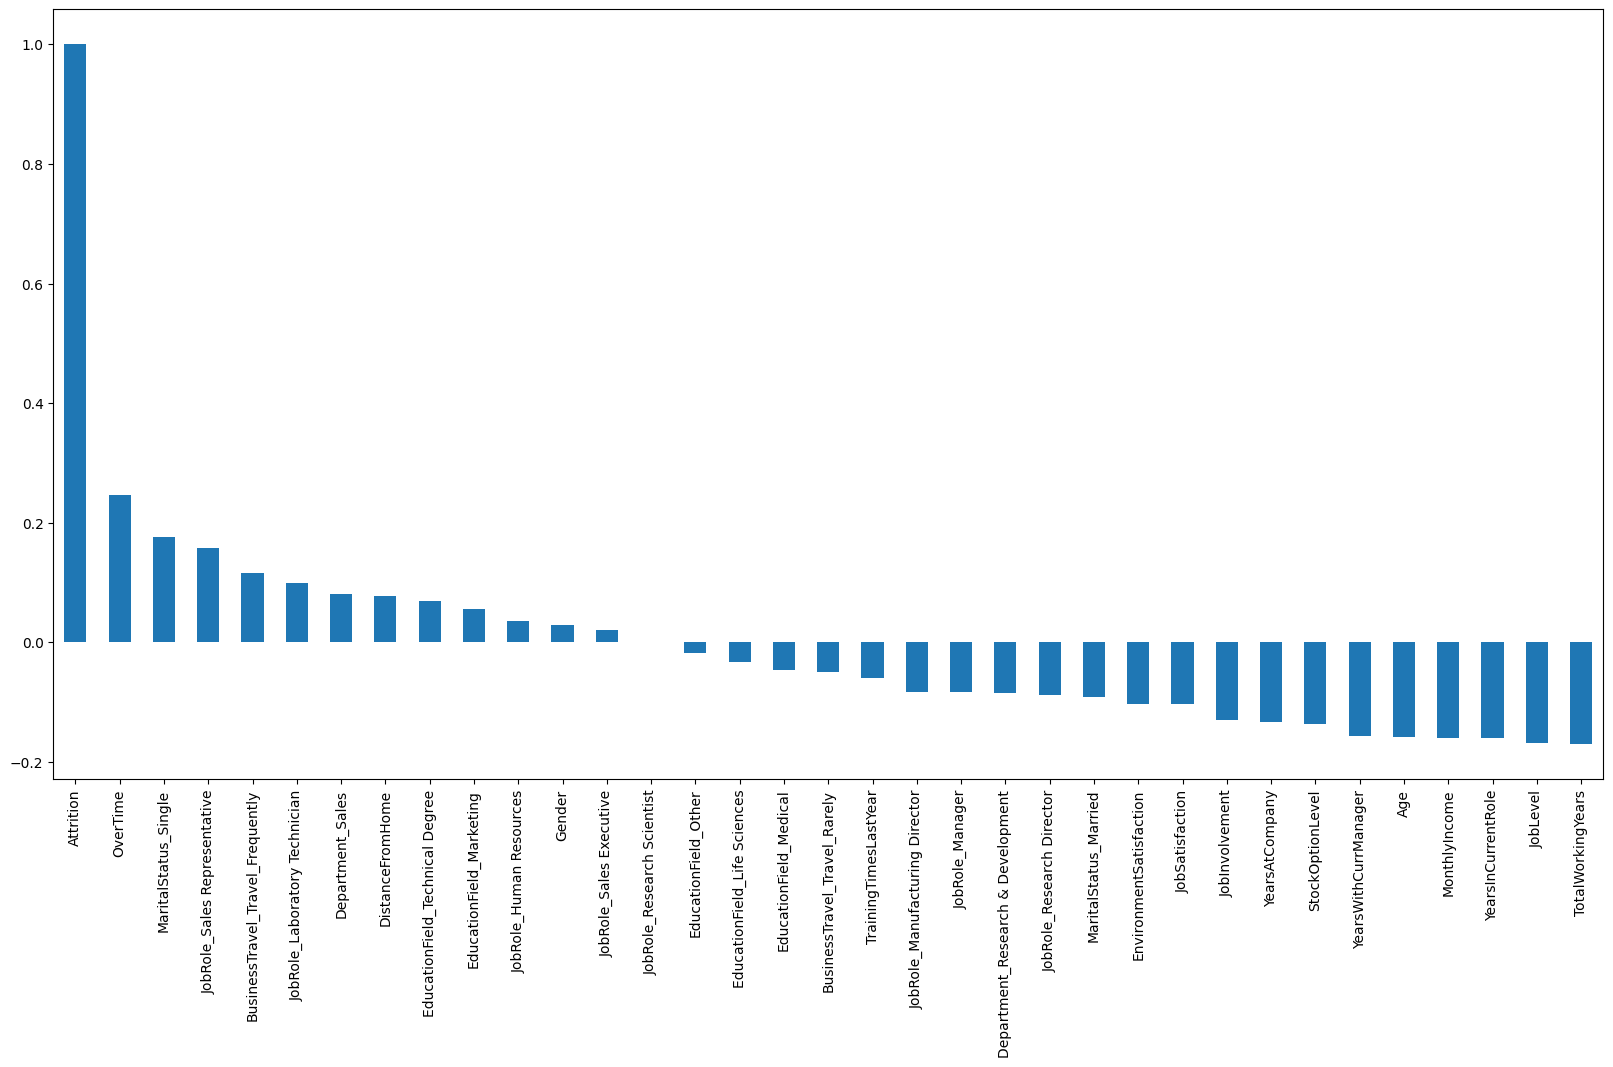

In [14]:
plt.figure(figsize=(20,10))
correlations=encoded_df.corr()
correlations['Attrition'].sort_values(ascending = False).plot(kind='bar');

# Importing Machine learning libraries

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Making Predictors and Target Separate

In [16]:
X = encoded_df.drop('Attrition',axis=1)
y = encoded_df['Attrition'].copy()

# Splitting Data into Train set and Test set

In [17]:

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.15, random_state = 42)

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [19]:
import warnings
warnings.filterwarnings('ignore')

warnings.filterwarnings("ignore", message="Setting penalty=None will ignore the C and l1_ratio parameters")

# Pipeline for scaling and training for different Machine learning models

In [20]:
#from sklearn.compose import ColumnTransformer


# Model Pipelines and Grids


pipelines = {
    'logreg' : Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC())
    ]),

    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),

    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(random_state=42))
    ]),

    'XGBoost': Pipeline([
        ('clf', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
    ])
}


# Hyperparameter Grids

param_grids = {
    'logreg' : {
        'clf__penalty': ['l1', 'l2', None],
        'clf__solver': ['lbfgs', 'liblinear'],  # saga supports all penalties
        'clf__C': [0.01, 0.1, 1, 10, 100]
    },
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
        'clf__gamma': ['scale', 'auto']
    },
    'Decision Tree': {
        'clf__max_depth': [2,3, 5, 10, None],
        'clf__min_samples_split': [2, 5, 10]
    },
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9],
        'clf__weights': ['uniform', 'distance']
    },
    'Random Forest': {
        'clf__n_estimators': [200,300,400],
        'clf__max_depth': [5, 10, None]
    },
    'XGBoost': {
        'clf__n_estimators': [200,300,400],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.01, 0.1, 0.3]
    }
}

#SMOTE
from imblearn.over_sampling import SMOTE
oversampler=SMOTE(random_state=0)
smote_train, smote_target = oversampler.fit_resample(X_train,Y_train)

# 🧠 Training and Evaluation


results = {}

for name, pipeline in pipelines.items():
    print(f"\n🔹 Training {name} ...")
    grid = GridSearchCV(pipeline, param_grids[name], cv=5, n_jobs=-1, verbose=1)
    grid.fit(smote_train, smote_target)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    
    print(f"✅ {name} Best Accuracy: {acc:.4f}")
    print(f"Best Parameters: {grid.best_params_}")
    print(classification_report(Y_test, y_pred))

    results[name] = {
        'accuracy': acc,
        'best_params': grid.best_params_
    }


# Compare All Models

print("\nModel Comparison:")
for name, info in results.items():
    print(f"{name}: {info['accuracy']:.4f} | Best Params: {info['best_params']}")


🔹 Training logreg ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅ logreg Best Accuracy: 0.7964
Best Parameters: {'clf__C': 0.01, 'clf__penalty': None, 'clf__solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.92      0.83      0.88       190
           1       0.36      0.58      0.44        31

    accuracy                           0.80       221
   macro avg       0.64      0.71      0.66       221
weighted avg       0.84      0.80      0.81       221


🔹 Training SVM ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ SVM Best Accuracy: 0.8235
Best Parameters: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       190
           1       0.37      0.35      0.36        31

    accuracy                           0.82       221
   macro avg       0.63      0.63      0.63       221
weighted avg       

# Best Model

In [21]:
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model_info = results[best_model_name]

print("\nBest Model Summary:")
print(f"Model: {best_model_name}")
print(f"Accuracy: {best_model_info['accuracy']:.4f}")
print(f"Best Parameters: {best_model_info['best_params']}")


Best Model Summary:
Model: XGBoost
Accuracy: 0.8688
Best Parameters: {'clf__learning_rate': 0.3, 'clf__max_depth': 5, 'clf__n_estimators': 400}
